# Amazon Beauty

In [ ]:
import pandas as pd

print("1. Đang đọc dữ liệu (chỉ lấy 50.000 dòng để test)...")
# Thay tên file bằng đúng tên file bạn đã tải về nhé
review_file = '/content/All_Beauty.jsonl.gz'
meta_file = '/content/meta_All_Beauty.jsonl.gz'

# Đọc dữ liệu
df_review = pd.read_json(review_file, lines=True, compression='gzip', nrows=50000)
df_meta = pd.read_json(meta_file, lines=True, compression='gzip', nrows=50000)

print("2. Đang xử lý chuỗi thời gian...")
# Chuyển đổi timestamp từ miligiây sang định dạng Ngày-Tháng
df_review['date'] = pd.to_datetime(df_review['timestamp'], unit='ms')

# Tạo thêm một cột 'Tháng-Năm' để gộp nhóm dữ liệu theo tháng
df_review['month_year'] = df_review['date'].dt.to_period('M')

print("3. Đang lọc cột và ghép nối (Merge) 2 bảng...")
# Chỉ giữ lại các cột cần thiết để tối ưu bộ nhớ RAM
review_subset = df_review[['parent_asin', 'date', 'month_year', 'rating']]
meta_subset = df_meta[['parent_asin', 'title']] # Lấy mã sản phẩm và tên sản phẩm

# Nối 2 bảng dựa trên 'chìa khóa' là parent_asin
df_merged = pd.merge(review_subset, meta_subset, on='parent_asin', how='inner')

print("4. Đang tạo bộ dữ liệu Time Series...")
# Gộp nhóm theo Từng sản phẩm + Từng tháng
# Tính tổng số lượng đánh giá (review_count) và Điểm trung bình (avg_rating)
df_time_series = df_merged.groupby(['parent_asin', 'title', 'month_year']).agg(
    review_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Sắp xếp lại theo tên sản phẩm và thời gian tăng dần
df_time_series = df_time_series.sort_values(by=['parent_asin', 'month_year'])

print("\n=== KẾT QUẢ: BỘ DỮ LIỆU TIME SERIES HOÀN CHỈNH ===")
display(df_time_series.head(10)) # Nếu dùng file .py bình thường thì đổi thành print(df_time_series.head(10))

# 5. Lưu kết quả ra file CSV để dùng cho các bước huấn luyện mô hình sau này
# df_time_series.to_csv('amazon_time_series_data.csv', index=False, encoding='utf-8-sig')
# print("\nĐã lưu file amazon_time_series_data.csv thành công!")

1. Đang đọc dữ liệu (chỉ lấy 50.000 dòng để test)...
2. Đang xử lý chuỗi thời gian...
3. Đang lọc cột và ghép nối (Merge) 2 bảng...
4. Đang tạo bộ dữ liệu Time Series...

=== KẾT QUẢ: BỘ DỮ LIỆU TIME SERIES HOÀN CHỈNH ===


,parent_asin,title,month_year,review_count,avg_rating
0,069267599X,Inspirational Card Deck,2017-04,1,2.0
1,069267599X,Inspirational Card Deck,2019-01,1,5.0
2,069267599X,Inspirational Card Deck,2021-04,1,5.0
3,069267599X,Inspirational Card Deck,2021-06,1,5.0
4,0990995119,Pediatric Cardiac Intensive Care Handbook,2021-04,1,5.0
5,3862336476,Das große Jahreszeiten-Wimmelbuch,2014-10,1,5.0
6,6075085491,"10 x French, Chevron & Teardrop Nail Tip Guide...",2015-02,1,5.0
7,9788077587,Natori Perfume For Her Eau De Parfum 7.5 ml Sp...,2019-03,1,5.0
8,979077530X,Versace Man Eau Fraiche 3.4 oz Eau de Toilette...,2016-09,1,5.0
9,979077530X,Versace Man Eau Fraiche 3.4 oz Eau de Toilette...,2017-06,1,5.0


In [ ]:
# Đảm bảo cột 'date' đang ở định dạng datetime. Cột 'date' không tồn tại trong df_time_series,
# nên ta sẽ tạo nó từ 'month_year' bằng cách lấy ngày đầu tiên của tháng.
df_time_series['date'] = df_time_series['month_year'].dt.to_timestamp()

print("Ngày lớn nhất trong dữ liệu CŨ:", df_time_series['date'].max())

# 1. Dịch chuyển thời gian lên 28 tháng (Từ cuối 2023 lên hiện tại 04/2026)
df_simulated = df_time_series.copy()
df_simulated['date'] = df_simulated['date'] + pd.DateOffset(months=37)

# 2. Cập nhật lại cột 'month_year' cho khớp với cột date mới
df_simulated['month_year'] = df_simulated['date'].dt.to_period('M')

print("Ngày lớn nhất trong dữ liệu GIẢ LẬP:", df_simulated['date'].max())
display(df_simulated.tail())

Ngày lớn nhất trong dữ liệu CŨ: 2023-03-01 00:00:00
Ngày lớn nhất trong dữ liệu GIẢ LẬP: 2026-04-01 00:00:00


,parent_asin,title,month_year,review_count,avg_rating,date
22418,B0C9CWKY9G,Picoway 20 Pack Mouse Ears Solid Black and Red...,2025-11,1,5.0,2025-11-01
22419,B0C9CWKY9G,Picoway 20 Pack Mouse Ears Solid Black and Red...,2025-12,1,5.0,2025-12-01
22420,B0C9CWKY9G,Picoway 20 Pack Mouse Ears Solid Black and Red...,2026-01,2,5.0,2026-01-01
22421,B0C9CWKY9G,Picoway 20 Pack Mouse Ears Solid Black and Red...,2026-02,1,5.0,2026-02-01
22422,B0C9CWKY9G,Picoway 20 Pack Mouse Ears Solid Black and Red...,2026-04,1,5.0,2026-04-01


In [ ]:
df_simulated.to_csv('amazon_mocked_data_beauty_2026.csv', index=False)

In [ ]:
df_simulated

,parent_asin,title,month_year,review_count,avg_rating,date
0,069267599X,Inspirational Card Deck,2020-05,1,2.0,2020-05-01
1,069267599X,Inspirational Card Deck,2022-02,1,5.0,2022-02-01
2,069267599X,Inspirational Card Deck,2024-05,1,5.0,2024-05-01
3,069267599X,Inspirational Card Deck,2024-07,1,5.0,2024-07-01
4,0990995119,Pediatric Cardiac Intensive Care Handbook,2024-05,1,5.0,2024-05-01
...,...,...,...,...,...,...
22418,B0C9CWKY9G,Picoway 20 Pack Mouse Ears Solid Black and Red...,2025-11,1,5.0,2025-11-01
22419,B0C9CWKY9G,Picoway 20 Pack Mouse Ears Solid Black and Red...,2025-12,1,5.0,2025-12-01
22420,B0C9CWKY9G,Picoway 20 Pack Mouse Ears Solid Black and Red...,2026-01,2,5.0,2026-01-01
22421,B0C9CWKY9G,Picoway 20 Pack Mouse Ears Solid Black and Red...,2026-02,1,5.0,2026-02-01


# Amazon Fashion

In [ ]:
import pandas as pd

print("1. Đang đọc dữ liệu (chỉ lấy 50.000 dòng để test)...")
# Thay tên file bằng đúng tên file bạn đã tải về nhé
review_file = '/content/Amazon_Fashion.jsonl.gz'
meta_file = '/content/meta_Amazon_Fashion.jsonl.gz'

# Đọc dữ liệu
df_review = pd.read_json(review_file, lines=True, compression='gzip', nrows=50000)
df_meta = pd.read_json(meta_file, lines=True, compression='gzip', nrows=50000)

print("2. Đang xử lý chuỗi thời gian...")
# Chuyển đổi timestamp từ miligiây sang định dạng Ngày-Tháng
df_review['date'] = pd.to_datetime(df_review['timestamp'], unit='ms')

# Tạo thêm một cột 'Tháng-Năm' để gộp nhóm dữ liệu theo tháng
df_review['month_year'] = df_review['date'].dt.to_period('M')

print("3. Đang lọc cột và ghép nối (Merge) 2 bảng...")
# Chỉ giữ lại các cột cần thiết để tối ưu bộ nhớ RAM
review_subset = df_review[['parent_asin', 'date', 'month_year', 'rating']]
meta_subset = df_meta[['parent_asin', 'title']] # Lấy mã sản phẩm và tên sản phẩm

# Nối 2 bảng dựa trên 'chìa khóa' là parent_asin
df_merged = pd.merge(review_subset, meta_subset, on='parent_asin', how='inner')

print("4. Đang tạo bộ dữ liệu Time Series...")
# Gộp nhóm theo Từng sản phẩm + Từng tháng
# Tính tổng số lượng đánh giá (review_count) và Điểm trung bình (avg_rating)
df_time_series = df_merged.groupby(['parent_asin', 'title', 'month_year']).agg(
    review_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Sắp xếp lại theo tên sản phẩm và thời gian tăng dần
df_time_series = df_time_series.sort_values(by=['parent_asin', 'month_year'])

print("\n=== KẾT QUẢ: BỘ DỮ LIỆU TIME SERIES HOÀN CHỈNH ===")
display(df_time_series.head(10)) # Nếu dùng file .py bình thường thì đổi thành print(df_time_series.head(10))

# 5. Lưu kết quả ra file CSV để dùng cho các bước huấn luyện mô hình sau này
# df_time_series.to_csv('amazon_time_series_data.csv', index=False, encoding='utf-8-sig')
# print("\nĐã lưu file amazon_time_series_data.csv thành công!")
# Đảm bảo cột 'date' đang ở định dạng datetime. Cột 'date' không tồn tại trong df_time_series,
# nên ta sẽ tạo nó từ 'month_year' bằng cách lấy ngày đầu tiên của tháng.
df_time_series['date'] = df_time_series['month_year'].dt.to_timestamp()

print("Ngày lớn nhất trong dữ liệu CŨ:", df_time_series['date'].max())

# 1. Dịch chuyển thời gian lên 28 tháng (Từ cuối 2023 lên hiện tại 04/2026)
df_simulated = df_time_series.copy()
df_simulated['date'] = df_simulated['date'] + pd.DateOffset(months=37)

# 2. Cập nhật lại cột 'month_year' cho khớp với cột date mới
df_simulated['month_year'] = df_simulated['date'].dt.to_period('M')

print("Ngày lớn nhất trong dữ liệu GIẢ LẬP:", df_simulated['date'].max())
display(df_simulated.tail())
df_simulated.to_csv('amazon_mocked_data_fashion_2026.csv', index=False)

1. Đang đọc dữ liệu (chỉ lấy 50.000 dòng để test)...
2. Đang xử lý chuỗi thời gian...
3. Đang lọc cột và ghép nối (Merge) 2 bảng...
4. Đang tạo bộ dữ liệu Time Series...

=== KẾT QUẢ: BỘ DỮ LIỆU TIME SERIES HOÀN CHỈNH ===


,parent_asin,title,month_year,review_count,avg_rating
0,B000090LW1,Fontanelli Classic Italian Leather Adjustable ...,2008-02,1,5.0
1,B0001ZYLZ4,Aqua LEISURE Kemp 50 Inch Rescue Tube withGuar...,2013-07,1,5.0
2,B00065G10W,Dan's Jewelers Irish Knot Celtic Adder Snake N...,2008-11,1,4.0
3,B0007MV6PO,"Henschel Breezer Hat with Coolmax Band, Khaki,...",2017-07,1,5.0
4,B0007VZLH4,Gem Avenue Sterling Silver Made with Swarovski...,2012-06,1,4.0
5,B00094OQNY,925 Sterling Silver 6mm Marquise Cut Clear Cub...,2008-08,1,5.0
6,B0009PC1MG,Eastbay Men's Half-Split Two-Color Race Short ...,2016-02,1,3.0
7,B000H8M9VS,Corpse Bride Bouquet,2013-10,1,4.0
8,B000H8UJTW,Doll Trunk for 18 inch Dolls,2013-12,1,1.0
9,B000J4J8BY,Gold Tone over Sterling Silver Filigree Disc C...,2009-09,1,5.0


Ngày lớn nhất trong dữ liệu CŨ: 2023-03-01 00:00:00
Ngày lớn nhất trong dữ liệu GIẢ LẬP: 2026-04-01 00:00:00


,parent_asin,title,month_year,review_count,avg_rating,date
5192,B0C4WSH5LC,Go2Socks Women's Standard Athletic Compression,2026-02,2,3.0,2026-02-01
5193,B0C52BMZ7X,J75 by Jump Men's Motorcycle Boots,2025-07,1,5.0,2025-07-01
5194,B0C5RBD59M,JCBFUME Cowl Hood Scarf Rogue Hood Medieval Cl...,2025-12,1,4.0,2025-12-01
5195,B0C69H7BC2,RIIQIICHY 100% Mulberry Silk Scarf Head Scarf ...,2024-05,1,5.0,2024-05-01
5196,B0C6DV6ZBR,EMIRISTIC Personalized Photo Bracelet With Pic...,2025-12,1,5.0,2025-12-01


# Amazon Handmade

In [ ]:
import pandas as pd

print("1. Đang đọc dữ liệu (chỉ lấy 50.000 dòng để test)...")
# Thay tên file bằng đúng tên file bạn đã tải về nhé
review_file = '/content/Handmade_Products.jsonl.gz'
meta_file = '/content/meta_Handmade_Products.jsonl.gz'

# Đọc dữ liệu
df_review = pd.read_json(review_file, lines=True, compression='gzip', nrows=50000)
df_meta = pd.read_json(meta_file, lines=True, compression='gzip', nrows=50000)

print("2. Đang xử lý chuỗi thời gian...")
# Chuyển đổi timestamp từ miligiây sang định dạng Ngày-Tháng
df_review['date'] = pd.to_datetime(df_review['timestamp'], unit='ms')

# Tạo thêm một cột 'Tháng-Năm' để gộp nhóm dữ liệu theo tháng
df_review['month_year'] = df_review['date'].dt.to_period('M')

print("3. Đang lọc cột và ghép nối (Merge) 2 bảng...")
# Chỉ giữ lại các cột cần thiết để tối ưu bộ nhớ RAM
review_subset = df_review[['parent_asin', 'date', 'month_year', 'rating']]
meta_subset = df_meta[['parent_asin', 'title']] # Lấy mã sản phẩm và tên sản phẩm

# Nối 2 bảng dựa trên 'chìa khóa' là parent_asin
df_merged = pd.merge(review_subset, meta_subset, on='parent_asin', how='inner')

print("4. Đang tạo bộ dữ liệu Time Series...")
# Gộp nhóm theo Từng sản phẩm + Từng tháng
# Tính tổng số lượng đánh giá (review_count) và Điểm trung bình (avg_rating)
df_time_series = df_merged.groupby(['parent_asin', 'title', 'month_year']).agg(
    review_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Sắp xếp lại theo tên sản phẩm và thời gian tăng dần
df_time_series = df_time_series.sort_values(by=['parent_asin', 'month_year'])

print("\n=== KẾT QUẢ: BỘ DỮ LIỆU TIME SERIES HOÀN CHỈNH ===")
display(df_time_series.head(10)) # Nếu dùng file .py bình thường thì đổi thành print(df_time_series.head(10))

# 5. Lưu kết quả ra file CSV để dùng cho các bước huấn luyện mô hình sau này
# df_time_series.to_csv('amazon_time_series_data.csv', index=False, encoding='utf-8-sig')
# print("\nĐã lưu file amazon_time_series_data.csv thành công!")
# Đảm bảo cột 'date' đang ở định dạng datetime. Cột 'date' không tồn tại trong df_time_series,
# nên ta sẽ tạo nó từ 'month_year' bằng cách lấy ngày đầu tiên của tháng.
df_time_series['date'] = df_time_series['month_year'].dt.to_timestamp()

print("Ngày lớn nhất trong dữ liệu CŨ:", df_time_series['date'].max())

# 1. Dịch chuyển thời gian lên 28 tháng (Từ cuối 2023 lên hiện tại 04/2026)
df_simulated = df_time_series.copy()
df_simulated['date'] = df_simulated['date'] + pd.DateOffset(months=37)

# 2. Cập nhật lại cột 'month_year' cho khớp với cột date mới
df_simulated['month_year'] = df_simulated['date'].dt.to_period('M')

print("Ngày lớn nhất trong dữ liệu GIẢ LẬP:", df_simulated['date'].max())
display(df_simulated.tail())
df_simulated.to_csv('amazon_mocked_data_handmade_2026.csv', index=False)

1. Đang đọc dữ liệu (chỉ lấy 50.000 dòng để test)...
2. Đang xử lý chuỗi thời gian...
3. Đang lọc cột và ghép nối (Merge) 2 bảng...
4. Đang tạo bộ dữ liệu Time Series...

=== KẾT QUẢ: BỘ DỮ LIỆU TIME SERIES HOÀN CHỈNH ===


,parent_asin,title,month_year,review_count,avg_rating
0,B001RMDSQ8,Seeka Turquoise Peace Dove Necklace - N0062OR,2021-10,1,4.0
1,B001RMKWM6,Seeka Adorned Hamsa Necklace - N2412M,2014-07,1,5.0
2,B009EU7Y74,"La Contessa Jewelry, Rabbit and Flower Earring...",2013-12,1,5.0
3,B00DVXVQIS,Gold Toe Ring One Size Fits All Most Adjustable,2017-01,1,5.0
4,B00GDFQFMI,Vintage Botanical Flower Art Print: Lilac,2017-10,1,3.0
5,B00N122N5O,I Work Hard So My Cats Can Have a Better Life ...,2015-10,1,5.0
6,B00N125C0W,5 Deadly Terms Used by a Woman Funny Sign in P...,2016-10,1,5.0
7,B00WKF9NSI,Customizable Nursery Door Sign Red Polka Dots ...,2018-10,1,5.0
8,B014OE4NDC,Paper Bead Multi Strand Elements Necklace - Ea...,2016-02,1,5.0
9,B014PYPCVS,Recycled Paper Bead Cluster Musana Earrings - ...,2016-02,1,4.0


Ngày lớn nhất trong dữ liệu CŨ: 2023-03-01 00:00:00
Ngày lớn nhất trong dữ liệu GIẢ LẬP: 2026-04-01 00:00:00


,parent_asin,title,month_year,review_count,avg_rating,date
19434,B0C9FQJS34,"Beets and Apples Thank You Gift for Women, App...",2024-04,1,5.0,2024-04-01
19435,B0C9FQJS34,"Beets and Apples Thank You Gift for Women, App...",2025-02,1,5.0,2025-02-01
19436,B0C9FQJS34,"Beets and Apples Thank You Gift for Women, App...",2025-05,1,5.0,2025-05-01
19437,B0C9FQJS34,"Beets and Apples Thank You Gift for Women, App...",2025-07,1,2.0,2025-07-01
19438,B0C9FQJS34,"Beets and Apples Thank You Gift for Women, App...",2026-02,1,5.0,2026-02-01


# Amazon Health and Personal

In [ ]:
import pandas as pd

print("1. Đang đọc dữ liệu (chỉ lấy 50.000 dòng để test)...")
# Thay tên file bằng đúng tên file bạn đã tải về nhé
review_file = '/content/Health_and_Personal_Care.jsonl.gz'
meta_file = '/content/meta_Health_and_Personal_Care.jsonl.gz'

# Đọc dữ liệu
df_review = pd.read_json(review_file, lines=True, compression='gzip', nrows=50000)
df_meta = pd.read_json(meta_file, lines=True, compression='gzip', nrows=50000)

print("2. Đang xử lý chuỗi thời gian...")
# Chuyển đổi timestamp từ miligiây sang định dạng Ngày-Tháng
df_review['date'] = pd.to_datetime(df_review['timestamp'], unit='ms')

# Tạo thêm một cột 'Tháng-Năm' để gộp nhóm dữ liệu theo tháng
df_review['month_year'] = df_review['date'].dt.to_period('M')

print("3. Đang lọc cột và ghép nối (Merge) 2 bảng...")
# Chỉ giữ lại các cột cần thiết để tối ưu bộ nhớ RAM
review_subset = df_review[['parent_asin', 'date', 'month_year', 'rating']]
meta_subset = df_meta[['parent_asin', 'title']] # Lấy mã sản phẩm và tên sản phẩm

# Nối 2 bảng dựa trên 'chìa khóa' là parent_asin
df_merged = pd.merge(review_subset, meta_subset, on='parent_asin', how='inner')

print("4. Đang tạo bộ dữ liệu Time Series...")
# Gộp nhóm theo Từng sản phẩm + Từng tháng
# Tính tổng số lượng đánh giá (review_count) và Điểm trung bình (avg_rating)
df_time_series = df_merged.groupby(['parent_asin', 'title', 'month_year']).agg(
    review_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Sắp xếp lại theo tên sản phẩm và thời gian tăng dần
df_time_series = df_time_series.sort_values(by=['parent_asin', 'month_year'])

print("\n=== KẾT QUẢ: BỘ DỮ LIỆU TIME SERIES HOÀN CHỈNH ===")
display(df_time_series.head(10)) # Nếu dùng file .py bình thường thì đổi thành print(df_time_series.head(10))

# 5. Lưu kết quả ra file CSV để dùng cho các bước huấn luyện mô hình sau này
# df_time_series.to_csv('amazon_time_series_data.csv', index=False, encoding='utf-8-sig')
# print("\nĐã lưu file amazon_time_series_data.csv thành công!")
# Đảm bảo cột 'date' đang ở định dạng datetime. Cột 'date' không tồn tại trong df_time_series,
# nên ta sẽ tạo nó từ 'month_year' bằng cách lấy ngày đầu tiên của tháng.
df_time_series['date'] = df_time_series['month_year'].dt.to_timestamp()

print("Ngày lớn nhất trong dữ liệu CŨ:", df_time_series['date'].max())

# 1. Dịch chuyển thời gian lên 28 tháng (Từ cuối 2023 lên hiện tại 04/2026)
df_simulated = df_time_series.copy()
df_simulated['date'] = df_simulated['date'] + pd.DateOffset(months=37)

# 2. Cập nhật lại cột 'month_year' cho khớp với cột date mới
df_simulated['month_year'] = df_simulated['date'].dt.to_period('M')

print("Ngày lớn nhất trong dữ liệu GIẢ LẬP:", df_simulated['date'].max())
display(df_simulated.tail())
df_simulated.to_csv('amazon_mocked_data_health_and_personal_2026.csv', index=False)

1. Đang đọc dữ liệu (chỉ lấy 50.000 dòng để test)...
2. Đang xử lý chuỗi thời gian...
3. Đang lọc cột và ghép nối (Merge) 2 bảng...
4. Đang tạo bộ dữ liệu Time Series...

=== KẾT QUẢ: BỘ DỮ LIỆU TIME SERIES HOÀN CHỈNH ===


,parent_asin,title,month_year,review_count,avg_rating
0,0545517451,Spookley the Square Pumpkin a Family to Be Tha...,2014-09,1,5.0
1,0705394638,C.r. Gibson Baby Boy Zoom-Zoom Loose-leaf Memo...,2013-12,1,5.0
2,0972004564,Canine Multiple Channel Charts,2014-12,1,3.0
3,0979073219,The Catholic Tide Continues to Turn,2013-07,1,4.0
4,0996499113,0,2015-12,1,5.0
5,1456605755,Beating Diabetes for Type 2 eBook 2012,2014-02,1,5.0
6,1465874399,Divya Mukta Vati (120 Tablets),2016-02,1,5.0
7,1465874399,Divya Mukta Vati (120 Tablets),2019-09,1,5.0
8,1465874399,Divya Mukta Vati (120 Tablets),2021-07,1,5.0
9,1465874399,Divya Mukta Vati (120 Tablets),2022-04,1,5.0


Ngày lớn nhất trong dữ liệu CŨ: 2023-03-01 00:00:00
Ngày lớn nhất trong dữ liệu GIẢ LẬP: 2026-04-01 00:00:00


,parent_asin,title,month_year,review_count,avg_rating,date
36891,B0CDDBK2G4,Arm & Hammer Pure Baking Soda Shaker - 12 Oz -...,2023-03,1,5.0,2023-03-01
36892,B0CDDBK2G4,Arm & Hammer Pure Baking Soda Shaker - 12 Oz -...,2024-01,1,5.0,2024-01-01
36893,B0CDDBK2G4,Arm & Hammer Pure Baking Soda Shaker - 12 Oz -...,2025-07,1,2.0,2025-07-01
36894,B0CGHBQZ3P,"Vinyl Fence Rail Clip (25 Pack) (1.5"")",2025-09,1,3.0,2025-09-01
36895,B0CGM9NF7G,Rapid Relief Reusable Hot & Cold Gel Compress ...,2026-04,1,5.0,2026-04-01


# Amazon Software

In [ ]:
import pandas as pd

print("1. Đang đọc dữ liệu (chỉ lấy 50.000 dòng để test)...")
# Thay tên file bằng đúng tên file bạn đã tải về nhé
review_file = '/content/Software.jsonl.gz'
meta_file = '/content/meta_Software.jsonl.gz'

# Đọc dữ liệu
df_review = pd.read_json(review_file, lines=True, compression='gzip', nrows=50000)
df_meta = pd.read_json(meta_file, lines=True, compression='gzip', nrows=50000)

print("2. Đang xử lý chuỗi thời gian...")
# Chuyển đổi timestamp từ miligiây sang định dạng Ngày-Tháng
df_review['date'] = pd.to_datetime(df_review['timestamp'], unit='ms')

# Tạo thêm một cột 'Tháng-Năm' để gộp nhóm dữ liệu theo tháng
df_review['month_year'] = df_review['date'].dt.to_period('M')

print("3. Đang lọc cột và ghép nối (Merge) 2 bảng...")
# Chỉ giữ lại các cột cần thiết để tối ưu bộ nhớ RAM
review_subset = df_review[['parent_asin', 'date', 'month_year', 'rating']]
meta_subset = df_meta[['parent_asin', 'title']] # Lấy mã sản phẩm và tên sản phẩm

# Nối 2 bảng dựa trên 'chìa khóa' là parent_asin
df_merged = pd.merge(review_subset, meta_subset, on='parent_asin', how='inner')

print("4. Đang tạo bộ dữ liệu Time Series...")
# Gộp nhóm theo Từng sản phẩm + Từng tháng
# Tính tổng số lượng đánh giá (review_count) và Điểm trung bình (avg_rating)
df_time_series = df_merged.groupby(['parent_asin', 'title', 'month_year']).agg(
    review_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

# Sắp xếp lại theo tên sản phẩm và thời gian tăng dần
df_time_series = df_time_series.sort_values(by=['parent_asin', 'month_year'])

print("\n=== KẾT QUẢ: BỘ DỮ LIỆU TIME SERIES HOÀN CHỈNH ===")
display(df_time_series.head(10)) # Nếu dùng file .py bình thường thì đổi thành print(df_time_series.head(10))

# 5. Lưu kết quả ra file CSV để dùng cho các bước huấn luyện mô hình sau này
# df_time_series.to_csv('amazon_time_series_data.csv', index=False, encoding='utf-8-sig')
# print("\nĐã lưu file amazon_time_series_data.csv thành công!")
# Đảm bảo cột 'date' đang ở định dạng datetime. Cột 'date' không tồn tại trong df_time_series,
# nên ta sẽ tạo nó từ 'month_year' bằng cách lấy ngày đầu tiên của tháng.
df_time_series['date'] = df_time_series['month_year'].dt.to_timestamp()

print("Ngày lớn nhất trong dữ liệu CŨ:", df_time_series['date'].max())

# 1. Dịch chuyển thời gian lên 28 tháng (Từ cuối 2023 lên hiện tại 04/2026)
df_simulated = df_time_series.copy()
df_simulated['date'] = df_simulated['date'] + pd.DateOffset(months=37)

# 2. Cập nhật lại cột 'month_year' cho khớp với cột date mới
df_simulated['month_year'] = df_simulated['date'].dt.to_period('M')

print("Ngày lớn nhất trong dữ liệu GIẢ LẬP:", df_simulated['date'].max())
display(df_simulated.tail())
df_simulated.to_csv('amazon_mocked_data_software_2026.csv', index=False)

1. Đang đọc dữ liệu (chỉ lấy 50.000 dòng để test)...
2. Đang xử lý chuỗi thời gian...
3. Đang lọc cột và ghép nối (Merge) 2 bảng...
4. Đang tạo bộ dữ liệu Time Series...

=== KẾT QUẢ: BỘ DỮ LIỆU TIME SERIES HOÀN CHỈNH ===


,parent_asin,title,month_year,review_count,avg_rating
0,0321700945,Adobe Photoshop Lightroom 3 Learn By Video,2014-06,1,5.0
1,0615179088,Human Japanese,2015-03,1,5.0
2,061591067X,Human Japanese Intermediate,2015-04,1,1.0
3,1426296355,Complete National Geographic: Every Issue Sinc...,2010-07,1,3.0
4,1592970362,Personal Ancestral File 5.2 (Includes Personal...,2015-04,1,5.0
5,1597627895,Drawing the Female Portrait: Construction and ...,2012-11,1,5.0
6,1608293017,Rosetta Stone Homeschool Spanish (Latin Americ...,2016-07,1,4.0
7,1608293017,Rosetta Stone Homeschool Spanish (Latin Americ...,2016-12,1,3.0
8,1617160075,Learn German: Rosetta Stone German - Level 1-5...,2014-01,1,1.0
9,1617160075,Learn German: Rosetta Stone German - Level 1-5...,2014-08,1,2.0


Ngày lớn nhất trong dữ liệu CŨ: 2023-03-01 00:00:00
Ngày lớn nhất trong dữ liệu GIẢ LẬP: 2026-04-01 00:00:00


,parent_asin,title,month_year,review_count,avg_rating,date
22221,B0BW5PZS1G,McAfee Total Protection 2023 | Unlimited Devic...,2024-01,1,2.0,2024-01-01
22222,B0BW5PZS1G,McAfee Total Protection 2023 | Unlimited Devic...,2024-10,1,5.0,2024-10-01
22223,B0BW5PZS1G,McAfee Total Protection 2023 | Unlimited Devic...,2024-12,1,3.0,2024-12-01
22224,B0BW5PZS1G,McAfee Total Protection 2023 | Unlimited Devic...,2025-08,1,4.0,2025-08-01
22225,B0C57HL7QY,"Roxio Toast 20 Pro | CD, DVD & Blu-ray Burner ...",2025-04,1,1.0,2025-04-01


In [ ]:
import pandas as pd
import re

# Danh sách các file CSV cần gộp
csv_files = [
    'amazon_mocked_data_beauty_2026.csv',
    'amazon_mocked_data_fashion_2026.csv',
    'amazon_mocked_data_handmade_2026.csv',
    'amazon_mocked_data_health_and_personal_2026.csv',
    'amazon_mocked_data_software_2026.csv'
]

# Tạo danh sách các DataFrame
dfs = []

print("Đang đọc và gộp các file CSV...")
for file in csv_files:
    try:
        df = pd.read_csv(file)
        # Extract product category from filename
        # Example: 'amazon_mocked_data_beauty_2026.csv' -> 'Beauty'
        category_match = re.search(r'amazon_mocked_data_([a-zA-Z_]+)_2026\.csv', file)
        if category_match:
            category = category_match.group(1).replace('_', ' ').title()
            df['product_category'] = category
        else:
            df['product_category'] = 'Other'

        dfs.append(df)
        print(f"Đã đọc {file} và thêm cột 'product_category' thành công.")
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file {file}. Vui lòng kiểm tra lại tên file và đường dẫn.")
    except Exception as e:
        print(f"Lỗi khi đọc file {file}: {e}")

# Gộp tất cả các DataFrame thành một
if dfs:
    df_combined = pd.concat(dfs, ignore_index=True)

    # Sắp xếp lại theo parent_asin và date để đảm bảo tính thời gian
    df_combined['date'] = pd.to_datetime(df_combined['date'])
    df_combined = df_combined.sort_values(by=['parent_asin', 'date']).reset_index(drop=True)

    # Lưu file đã gộp
    output_file = 'amazon_combined_mocked_data_2026.csv'
    df_combined.to_csv(output_file, index=False, encoding='utf-8-sig')
    print(f"\nĐã gộp thành công {len(dfs)} file và lưu vào '{output_file}'")
    print("Dữ liệu kết hợp (có cột 'product_category'):")
    display(df_combined.head())
    print(f"Tổng số dòng trong file đã gộp: {len(df_combined)}")
else:
    print("Không có file nào được đọc thành công để gộp.")

Đang đọc và gộp các file CSV...
Đã đọc amazon_mocked_data_beauty_2026.csv và thêm cột 'product_category' thành công.
Đã đọc amazon_mocked_data_fashion_2026.csv và thêm cột 'product_category' thành công.
Đã đọc amazon_mocked_data_handmade_2026.csv và thêm cột 'product_category' thành công.
Đã đọc amazon_mocked_data_health_and_personal_2026.csv và thêm cột 'product_category' thành công.
Đã đọc amazon_mocked_data_software_2026.csv và thêm cột 'product_category' thành công.

Đã gộp thành công 5 file và lưu vào 'amazon_combined_mocked_data_2026.csv'
Dữ liệu kết hợp (có cột 'product_category'):


,parent_asin,title,month_year,review_count,avg_rating,date,product_category
0,0321700945,Adobe Photoshop Lightroom 3 Learn By Video,2017-07,1,5.0,2017-07-01,Software
1,0545517451,Spookley the Square Pumpkin a Family to Be Tha...,2017-10,1,5.0,2017-10-01,Health And Personal
2,0615179088,Human Japanese,2018-04,1,5.0,2018-04-01,Software
3,061591067X,Human Japanese Intermediate,2018-05,1,1.0,2018-05-01,Software
4,069267599X,Inspirational Card Deck,2020-05,1,2.0,2020-05-01,Beauty


Tổng số dòng trong file đã gộp: 106181


In [ ]:
df_combined

,parent_asin,title,month_year,review_count,avg_rating,date,product_category
0,0321700945,Adobe Photoshop Lightroom 3 Learn By Video,2017-07,1,5.0,2017-07-01,Software
1,0545517451,Spookley the Square Pumpkin a Family to Be Tha...,2017-10,1,5.0,2017-10-01,Health And Personal
2,0615179088,Human Japanese,2018-04,1,5.0,2018-04-01,Software
3,061591067X,Human Japanese Intermediate,2018-05,1,1.0,2018-05-01,Software
4,069267599X,Inspirational Card Deck,2020-05,1,2.0,2020-05-01,Beauty
...,...,...,...,...,...,...,...
106176,B0CDDBK2G4,Arm & Hammer Pure Baking Soda Shaker - 12 Oz -...,2023-03,1,5.0,2023-03-01,Health And Personal
106177,B0CDDBK2G4,Arm & Hammer Pure Baking Soda Shaker - 12 Oz -...,2024-01,1,5.0,2024-01-01,Health And Personal
106178,B0CDDBK2G4,Arm & Hammer Pure Baking Soda Shaker - 12 Oz -...,2025-07,1,2.0,2025-07-01,Health And Personal
106179,B0CGHBQZ3P,"Vinyl Fence Rail Clip (25 Pack) (1.5"")",2025-09,1,3.0,2025-09-01,Health And Personal


1. Đang tải và tiền xử lý dữ liệu...
2. Lọc danh mục và tổng hợp dữ liệu...
3. Đang vẽ biểu đồ...
4. Lưu và hiển thị biểu đồ...


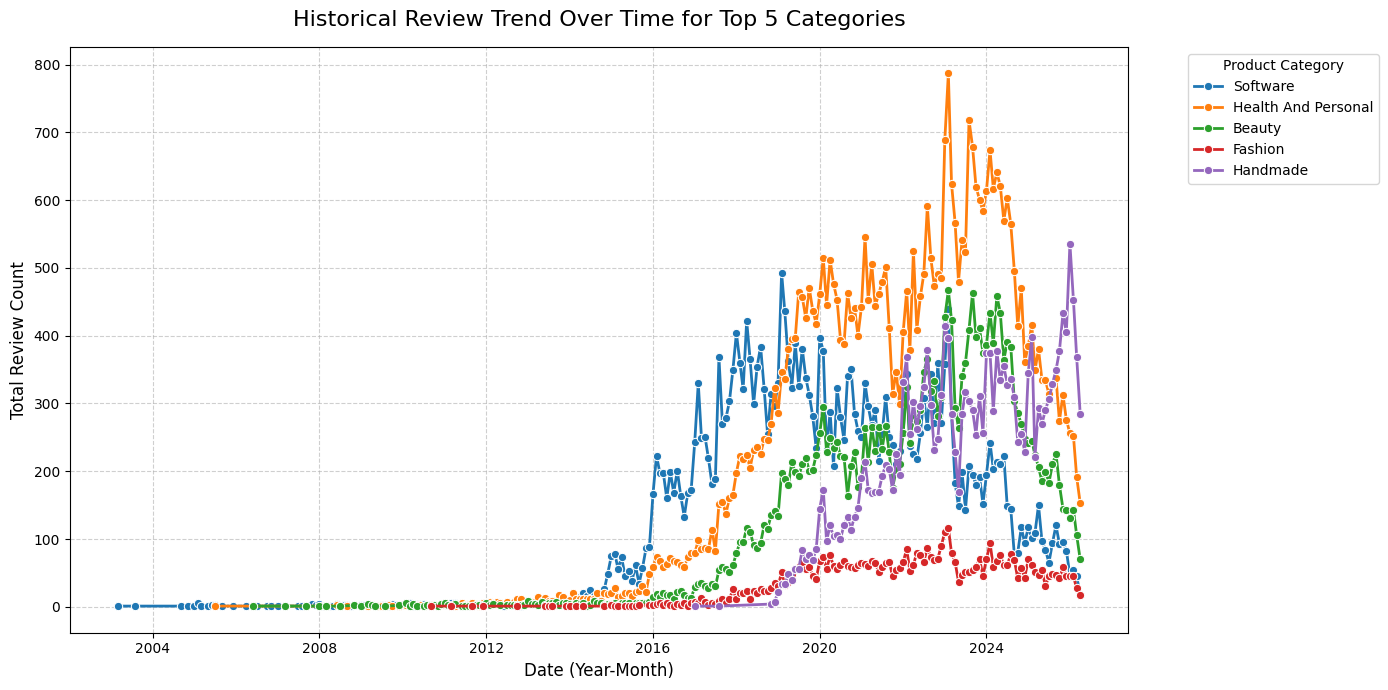

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_category_trend_linechart(file_path):
    print("1. Đang tải và tiền xử lý dữ liệu...")
    # Tải dữ liệu từ file CSV
    df = pd.read_csv(file_path)

    # Chuyển đổi cột 'date' sang định dạng thời gian (datetime) để vẽ biểu đồ
    df['date'] = pd.to_datetime(df['date'])

    print("2. Lọc danh mục và tổng hợp dữ liệu...")
    # Lấy 5 danh mục có dự báo xu hướng cao nhất (dựa vào kết quả của mô hình trước đó)
    top_categories = ['Handmade', 'Health And Personal', 'Beauty', 'Fashion', 'Software']

    # Lọc dữ liệu chỉ giữ lại các sản phẩm thuộc 5 danh mục trên
    df_top = df[df['product_category'].isin(top_categories)]

    # Nhóm dữ liệu theo Tháng (date) và Danh mục (product_category)
    # Sau đó tính tổng số lượng đánh giá (review_count) của mỗi nhóm trong tháng đó
    trend_data = df_top.groupby(['date', 'product_category'])['review_count'].sum().reset_index()

    print("3. Đang vẽ biểu đồ...")
    # Thiết lập kích thước khung hình cho biểu đồ (rộng 14, cao 7)
    plt.figure(figsize=(14, 7))

    # Sử dụng seaborn để vẽ biểu đồ đường (lineplot)
    # x='date': Trục hoành là thời gian
    # y='review_count': Trục tung là tổng số lượt đánh giá
    # hue='product_category': Vẽ các đường khác màu nhau dựa trên danh mục
    # marker='o': Đánh dấu các điểm dữ liệu bằng hình tròn
    sns.lineplot(data=trend_data, x='date', y='review_count', hue='product_category', marker='o', linewidth=2)

    # Cấu hình các tiêu đề và nhãn hiển thị trên biểu đồ
    plt.title('Historical Review Trend Over Time for Top 5 Categories', fontsize=16, pad=15)
    plt.xlabel('Date (Year-Month)', fontsize=12)
    plt.ylabel('Total Review Count', fontsize=12)

    # Đưa bảng chú thích (Legend) ra ngoài biểu đồ ở góc trên bên phải để không che khuất dữ liệu
    plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Hiển thị lưới để dễ nhìn các mức giá trị
    plt.grid(True, linestyle='--', alpha=0.6)

    # Tự động căn chỉnh các thành phần để không bị cắt lẹm
    plt.tight_layout()

    print("4. Lưu và hiển thị biểu đồ...")
    # Lưu biểu đồ thành file ảnh (chất lượng cao dpi=300)
    plt.savefig('category_trend_linechart.png', dpi=300)

    # Nếu chạy trên Jupyter Notebook hoặc máy cá nhân, dùng lệnh dưới đây để hiển thị
    plt.show()

# Gọi hàm thực thi (Nhớ đổi tên file trùng với file dữ liệu của bạn)
file_path = 'amazon_combined_mocked_data_2026.csv'
plot_category_trend_linechart(file_path)

In [ ]:
"""
=============================================================
MÔ HÌNH DỰ BÁO XU HƯỚNG SẢN PHẨM AMAZON
Dự báo 6 tháng tới theo Product Category
=============================================================
Yêu cầu: pip install pandas numpy scikit-learn
Input:   amazon_combined_mocked_data_2026.csv
Output:  trend_data.json  (dùng cho dashboard HTML)
=============================================================
"""

import pandas as pd
import numpy as np
import json
from datetime import datetime

# ─────────────────────────────────────────────
# 1. ĐỌC VÀ LÀM SẠCH DỮ LIỆU
# ─────────────────────────────────────────────
df = pd.read_csv("amazon_combined_mocked_data_2026.csv")
df["date"] = pd.to_datetime(df["date"])

# Chỉ dùng dữ liệu từ 2022 trở đi để tính YoY và huấn luyện mô hình
recent = df[df["date"] >= "2022-01-01"].copy()

# Tổng hợp theo danh mục + tháng
cat_monthly = (
    recent.groupby(["product_category", "date"])
    .agg(
        total_reviews=("review_count", "sum"),
        avg_rating=("avg_rating", "mean"),
        product_count=("parent_asin", "nunique"),
    )
    .reset_index()
    .sort_values("date")
)

# ─────────────────────────────────────────────
# 2. MÔ HÌNH DỰ BÁO (Polynomial Regression bậc 2)
# ─────────────────────────────────────────────
results = {}

for cat in cat_monthly["product_category"].unique():
    sub = cat_monthly[cat_monthly["product_category"] == cat].sort_values("date").reset_index(drop=True)

    # --- Tính YoY Growth (2025 vs 2024) ---
    y2025 = sub[sub["date"].dt.year == 2025]["total_reviews"].sum()
    y2024 = sub[sub["date"].dt.year == 2024]["total_reviews"].sum()
    yoy_growth = (y2025 - y2024) / (y2024 + 1e-9) * 100

    # --- Momentum: hệ số góc tuyến tính trên 6 tháng gần nhất ---
    last6 = sub.tail(6)
    slope = np.polyfit(np.arange(len(last6)), last6["total_reviews"].values, 1)[0] if len(last6) >= 3 else 0

    # --- Dự báo 6 tháng tới bằng hồi quy đa thức bậc 2 ---
    last12 = sub.tail(12).copy()
    last12["idx"] = np.arange(len(last12))
    x = last12["idx"].values

    # Reviews
    coeffs_rev  = np.polyfit(x, last12["total_reviews"].values, 2)
    # Rating
    coeffs_rat  = np.polyfit(x, last12["avg_rating"].values, 1)
    # Số sản phẩm
    coeffs_prod = np.polyfit(x, last12["product_count"].values, 2)

    future_idxs = np.arange(len(last12), len(last12) + 6)
    pred_reviews  = np.maximum(np.polyval(coeffs_rev,  future_idxs), 10)
    pred_ratings  = np.clip(np.polyval(coeffs_rat,  future_idxs), 1, 5)
    pred_products = np.maximum(np.polyval(coeffs_prod, future_idxs), 5)

    future_months = pd.date_range(start="2026-05-01", periods=6, freq="MS").strftime("%Y-%m").tolist()

    # --- Trend Score ---
    # Trọng số: YoY Growth (40%) + Momentum gần đây (30%) + Chất lượng rating (30%)
    avg_rating_now = float(sub.tail(3)["avg_rating"].mean())
    trend_score = (
        max(0, yoy_growth) * 0.4
        + max(0, slope)   * 0.3
        + avg_rating_now  * 5 * 0.3   # scale về ~0-25
    )

    results[cat] = {
        # Lịch sử từ 2023
        "historical_monthly": [
            {
                "month":    row["date"].strftime("%Y-%m"),
                "reviews":  int(row["total_reviews"]),
                "rating":   round(float(row["avg_rating"]), 2),
                "products": int(row["product_count"]),
            }
            for _, row in sub[sub["date"] >= "2023-01-01"].iterrows()
        ],
        # Dự báo 6 tháng tới
        "predictions": {
            "months":   future_months,
            "reviews":  [round(float(v)) for v in pred_reviews],
            "ratings":  [round(float(v), 2) for v in pred_ratings],
            "products": [round(float(v)) for v in pred_products],
        },
        # Các chỉ số đánh giá xu hướng
        "metrics": {
            "yoy_growth":  round(yoy_growth, 1),
            "momentum":    round(float(slope), 2),
            "avg_rating":  round(avg_rating_now, 2),
            "trend_score": round(float(trend_score), 1),
        },
    }

# ─────────────────────────────────────────────
# 3. CHUẨN HÓA ĐIỂM & XẾP HẠNG
# ─────────────────────────────────────────────
scores  = [results[c]["metrics"]["trend_score"] for c in results]
max_s   = max(scores) if max(scores) > 0 else 1
ranked  = sorted(results.keys(), key=lambda c: results[c]["metrics"]["trend_score"], reverse=True)

for rank, cat in enumerate(ranked, start=1):
    results[cat]["rank"] = rank
    results[cat]["metrics"]["normalized_score"] = round(
        results[cat]["metrics"]["trend_score"] / max_s * 100, 1
    )

# ─────────────────────────────────────────────
# 4. KẾT QUẢ & XUẤT FILE
# ─────────────────────────────────────────────
print("=" * 50)
print("XẾP HẠNG XU HƯỚNG 6 THÁNG TỚI")
print("=" * 50)
for cat in ranked:
    m = results[cat]["metrics"]
    print(
        f"#{results[cat]['rank']} {cat:<25}"
        f"  Score: {m['normalized_score']:>5.1f}/100"
        f"  YoY: {m['yoy_growth']:>+6.1f}%"
        f"  Rating: {m['avg_rating']:.2f}★"
    )

print("\nDỰ BÁO (reviews/tháng):")
for cat in ranked:
    p = results[cat]["predictions"]
    print(f"\n  {cat}:")
    for i, month in enumerate(p["months"]):
        print(f"    {month}: {p['reviews'][i]:>4} reviews  |  rating {p['ratings'][i]:.2f}★")

with open("trend_data.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("\nĐã lưu kết quả vào trend_data.json")

XẾP HẠNG XU HƯỚNG 6 THÁNG TỚI
#1 Handmade                   Score: 100.0/100  YoY:   +5.6%  Rating: 4.49★
#2 Fashion                    Score:  70.0/100  YoY:  -22.8%  Rating: 4.19★
#3 Health And Personal        Score:  67.8/100  YoY:  -39.2%  Rating: 4.07★
#4 Beauty                     Score:  66.7/100  YoY:  -45.1%  Rating: 4.01★
#5 Software                   Score:  62.2/100  YoY:  -38.0%  Rating: 3.75★

DỰ BÁO (reviews/tháng):

  Handmade:
    2026-05:  309 reviews  |  rating 4.48★
    2026-06:  260 reviews  |  rating 4.49★
    2026-07:  202 reviews  |  rating 4.50★
    2026-08:  136 reviews  |  rating 4.51★
    2026-09:   62 reviews  |  rating 4.52★
    2026-10:   10 reviews  |  rating 4.53★

  Fashion:
    2026-05:   15 reviews  |  rating 4.13★
    2026-06:   10 reviews  |  rating 4.13★
    2026-07:   10 reviews  |  rating 4.14★
    2026-08:   10 reviews  |  rating 4.14★
    2026-09:   10 reviews  |  rating 4.15★
    2026-10:   10 reviews  |  rating 4.15★

  Health And Personal:


In [ ]:
import pandas as pd
import json

print("1. Đang đọc file JSON...")
# Đọc file trend_data.json
with open('trend_data.json', 'r', encoding='utf-8') as f:
    trend_data = json.load(f)

# Danh sách để lưu các hàng dữ liệu dự báo
all_predictions = []

print("2. Đang trích xuất dữ liệu dự báo...")
for category, data in trend_data.items():
    predictions = data['predictions']

    for i in range(len(predictions['months'])):
        row = {
            'product_category': category,
            'forecast_month': predictions['months'][i],
            'predicted_reviews': predictions['reviews'][i],
            'predicted_ratings': predictions['ratings'][i],
            'predicted_products': predictions['products'][i]
        }
        all_predictions.append(row)

# Tạo DataFrame từ danh sách các dự báo
df_predictions = pd.DataFrame(all_predictions)

print("3. Đã tạo DataFrame dự báo:")
display(df_predictions.head())

# Lưu DataFrame thành file CSV
output_csv_file = 'trend_predictions.csv'
df_predictions.to_csv(output_csv_file, index=False, encoding='utf-8-sig')

print(f"\n4. Đã chuyển đổi thành công và lưu vào file '{output_csv_file}'")
print(f"Tổng số dòng trong file CSV: {len(df_predictions)}")

1. Đang đọc file JSON...
2. Đang trích xuất dữ liệu dự báo...
3. Đã tạo DataFrame dự báo:


,product_category,forecast_month,predicted_reviews,predicted_ratings,predicted_products
0,Beauty,2026-05,46,4.05,48
1,Beauty,2026-06,15,4.06,25
2,Beauty,2026-07,10,4.07,5
3,Beauty,2026-08,10,4.08,5
4,Beauty,2026-09,10,4.08,5



4. Đã chuyển đổi thành công và lưu vào file 'trend_predictions.csv'
Tổng số dòng trong file CSV: 30
